# TRENDY Decadal NBP Maps

Spatial plots of decadal-mean Net Biome Productivity (NBP) from TRENDY v2025 model runs.

- **Data source**: `decadal_grids/` — decadal-mean NBP on a common 2°×2° grid
- **Experiments**: S0, S1, S2, S3
- **Units**: kg C m⁻² s⁻¹ (positive = land carbon sink)
- **Decades**: 1700–2020 (labelled by start year)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glob
import re
from pathlib import Path

# ── Load all decadal grid files ──────────────────────────────────
files = sorted(glob.glob('decadal_grids/*_decadal_nbp.nc'))
print(f'Found {len(files)} decadal NetCDF files')

datasets = {}
for f in files:
    ds = xr.open_dataset(f)
    model = ds.attrs['model']
    exp   = ds.attrs['experiment']
    datasets[(model, exp)] = ds

models = sorted(set(k[0] for k in datasets))
experiments = ['S0', 'S1', 'S2', 'S3']
print(f'Models ({len(models)}): {", ".join(models)}')
print(f'Experiments: {experiments}')

# Unit conversion: kg C m-2 s-1 → g C m-2 yr-1
SEC_PER_YR = 365.25 * 24 * 3600
KG_TO_G = 1e3
UNIT_FACTOR = SEC_PER_YR * KG_TO_G  # multiply to get g C m-2 yr-1

Found 78 decadal NetCDF files
Models (20): CABLE-POP, CARDAMOM, CLASSIC, CLM-FATES, CLM6.0, DLEM, E3SM, EDv3, ELM-FATES, GDSTEM, IBIS, ISAM, JSBACH, JULES, LPJ-EOSIM, LPJ-GUESS, LPJmL, LPX-Bern, ORCHIDEE, VISIT-UT
Experiments: ['S0', 'S1', 'S2', 'S3']


## Multi-Model Mean Maps by Experiment — Recent Decades

Multi-model mean NBP for the most recent full decade (2010–2019) for each experiment.

/tmp/ipykernel_2073767/1531818723.py:26: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(stack, axis=0) * UNIT_FACTOR
/tmp/ipykernel_2073767/1531818723.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


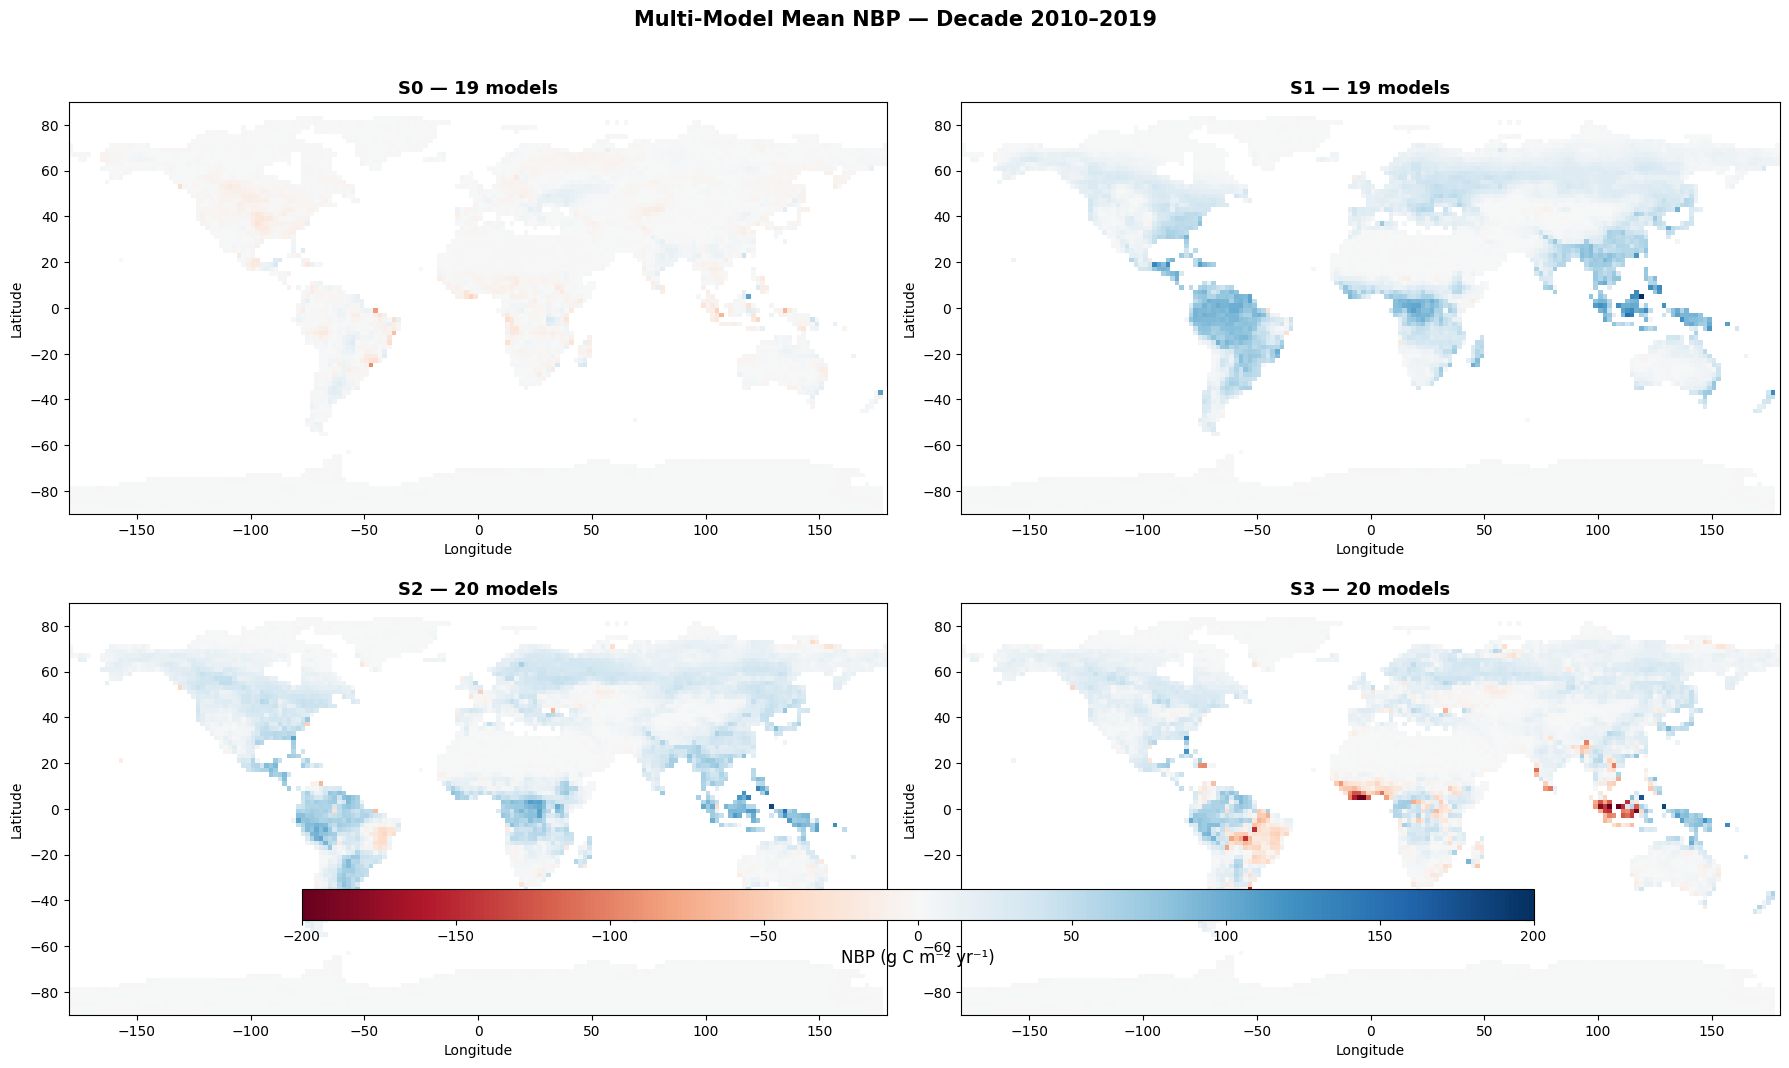

In [ ]:
target_decade = 2010

fig, axes = plt.subplots(2, 2, figsize=(18, 10),
                         subplot_kw={'projection': None})

# Diverging colourmap centred on zero
vmax = 200  # g C m-2 yr-1
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

for ax, exp in zip(axes.flat, experiments):
    # Stack all models that have this experiment and decade
    fields = []
    for model in models:
        if (model, exp) in datasets:
            ds = datasets[(model, exp)]
            if target_decade in ds.decade.values:
                fields.append(ds['nbp'].sel(decade=target_decade).values)
    
    if len(fields) == 0:
        ax.set_title(f'{exp} — no data')
        continue
    
    # Multi-model mean
    stack = np.array(fields)  # (n_models, lat, lon)
    mmm = np.nanmean(stack, axis=0) * UNIT_FACTOR
    
    lat = datasets[list(datasets.keys())[0]].lat.values
    lon = datasets[list(datasets.keys())[0]].lon.values
    
    im = ax.pcolormesh(lon, lat, mmm, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(f'{exp} — {len(fields)} models', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

fig.suptitle(f'Multi-Model Mean NBP — Decade {target_decade}–{target_decade+9}',
             fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.25)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.1, aspect=40)
cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=12)
plt.show()

## Temporal Evolution of Spatial Patterns — S3 (All Forcings)

Multi-model mean NBP maps for selected decades under S3 (full forcing).

/tmp/ipykernel_2073767/4152008786.py:27: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR


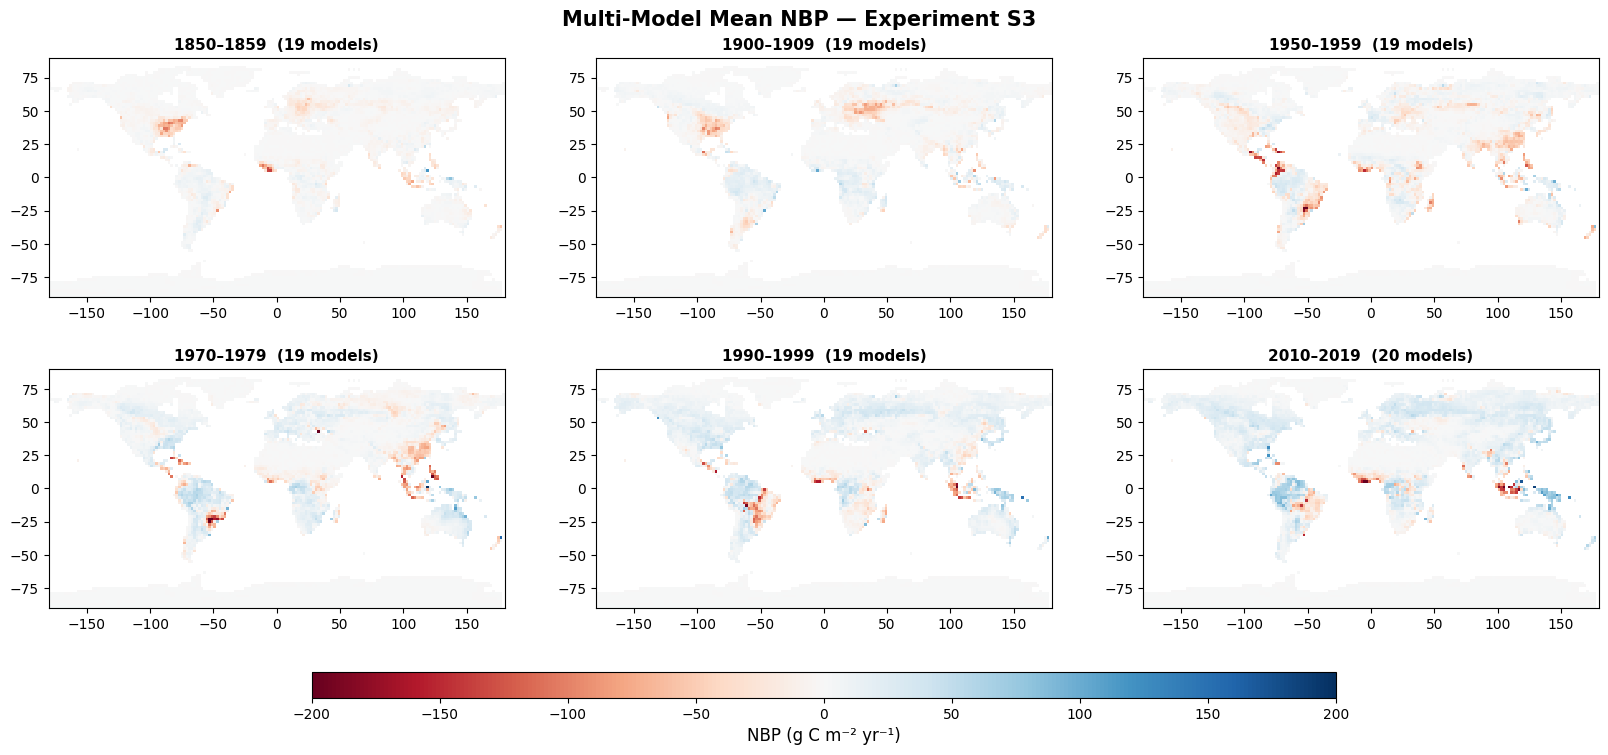

In [8]:
selected_decades = [1850, 1900, 1950, 1970, 1990, 2010]
exp = 'S3'

ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8))

vmax = 200
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

for ax, dec in zip(axes.flat, selected_decades):
    fields = []
    for model in models:
        if (model, exp) in datasets:
            ds = datasets[(model, exp)]
            if dec in ds.decade.values:
                fields.append(ds['nbp'].sel(decade=dec).values)
    
    if len(fields) == 0:
        ax.set_title(f'{dec}s — no data')
        continue
    
    mmm = np.nanmean(np.array(fields), axis=0) * UNIT_FACTOR
    im = ax.pcolormesh(lon, lat, mmm, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(f'{dec}–{dec+9}  ({len(fields)} models)', fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

fig.suptitle(f'Multi-Model Mean NBP — Experiment {exp}', fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.3)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.1, aspect=40)
cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=12)
plt.show()

## Land Use Effect Maps: S3 − S2

Multi-model mean difference S3 − S2 isolates the spatial fingerprint of land-use change.

/tmp/ipykernel_2073767/3429489916.py:26: RuntimeWarning: Mean of empty slice
  mmm_diff = np.nanmean(np.array(diffs), axis=0) * UNIT_FACTOR


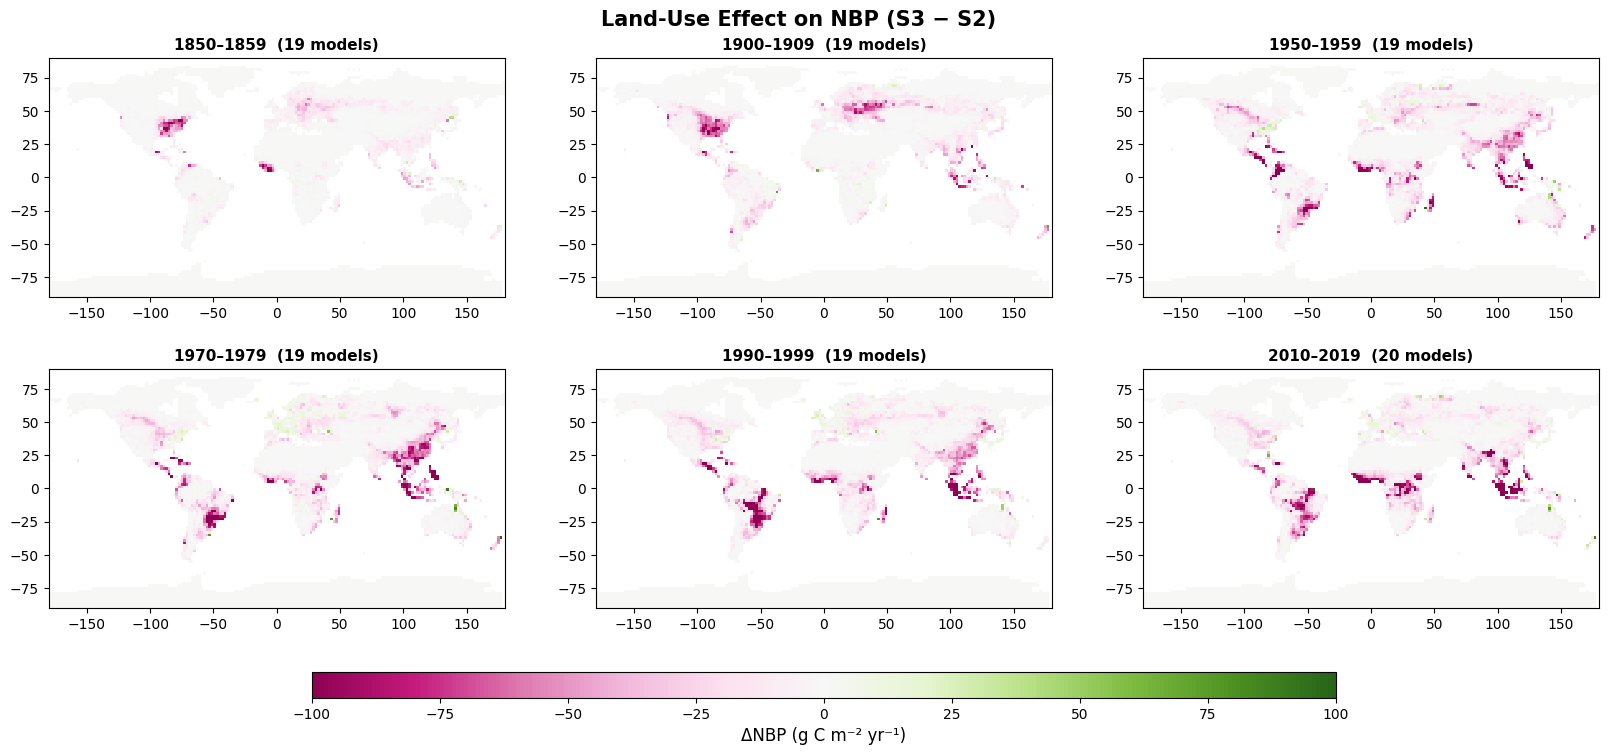

In [9]:
selected_decades_lu = [1850, 1900, 1950, 1970, 1990, 2010]

fig, axes = plt.subplots(2, 3, figsize=(20, 8))

vmax_lu = 100
norm_lu = mcolors.TwoSlopeNorm(vmin=-vmax_lu, vcenter=0, vmax=vmax_lu)
cmap_lu = 'PiYG'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

for ax, dec in zip(axes.flat, selected_decades_lu):
    diffs = []
    for model in models:
        has_s3 = (model, 'S3') in datasets and dec in datasets[(model, 'S3')].decade.values
        has_s2 = (model, 'S2') in datasets and dec in datasets[(model, 'S2')].decade.values
        if has_s3 and has_s2:
            s3_field = datasets[(model, 'S3')]['nbp'].sel(decade=dec).values
            s2_field = datasets[(model, 'S2')]['nbp'].sel(decade=dec).values
            diffs.append(s3_field - s2_field)
    
    if len(diffs) == 0:
        ax.set_title(f'{dec}s — no data')
        continue
    
    mmm_diff = np.nanmean(np.array(diffs), axis=0) * UNIT_FACTOR
    im = ax.pcolormesh(lon, lat, mmm_diff, cmap=cmap_lu, norm=norm_lu, shading='auto')
    ax.set_title(f'{dec}–{dec+9}  ({len(diffs)} models)', fontsize=11, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

fig.suptitle('Land-Use Effect on NBP (S3 − S2)', fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.12, top=0.92, hspace=0.3)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.04, pad=0.1, aspect=40)
cbar.set_label('ΔNBP (g C m⁻² yr⁻¹)', fontsize=12)
plt.show()

## Model Spread — Individual Model Maps (S3, 2010s)

NBP from each model for the 2010–2019 decade under S3 (all forcings).

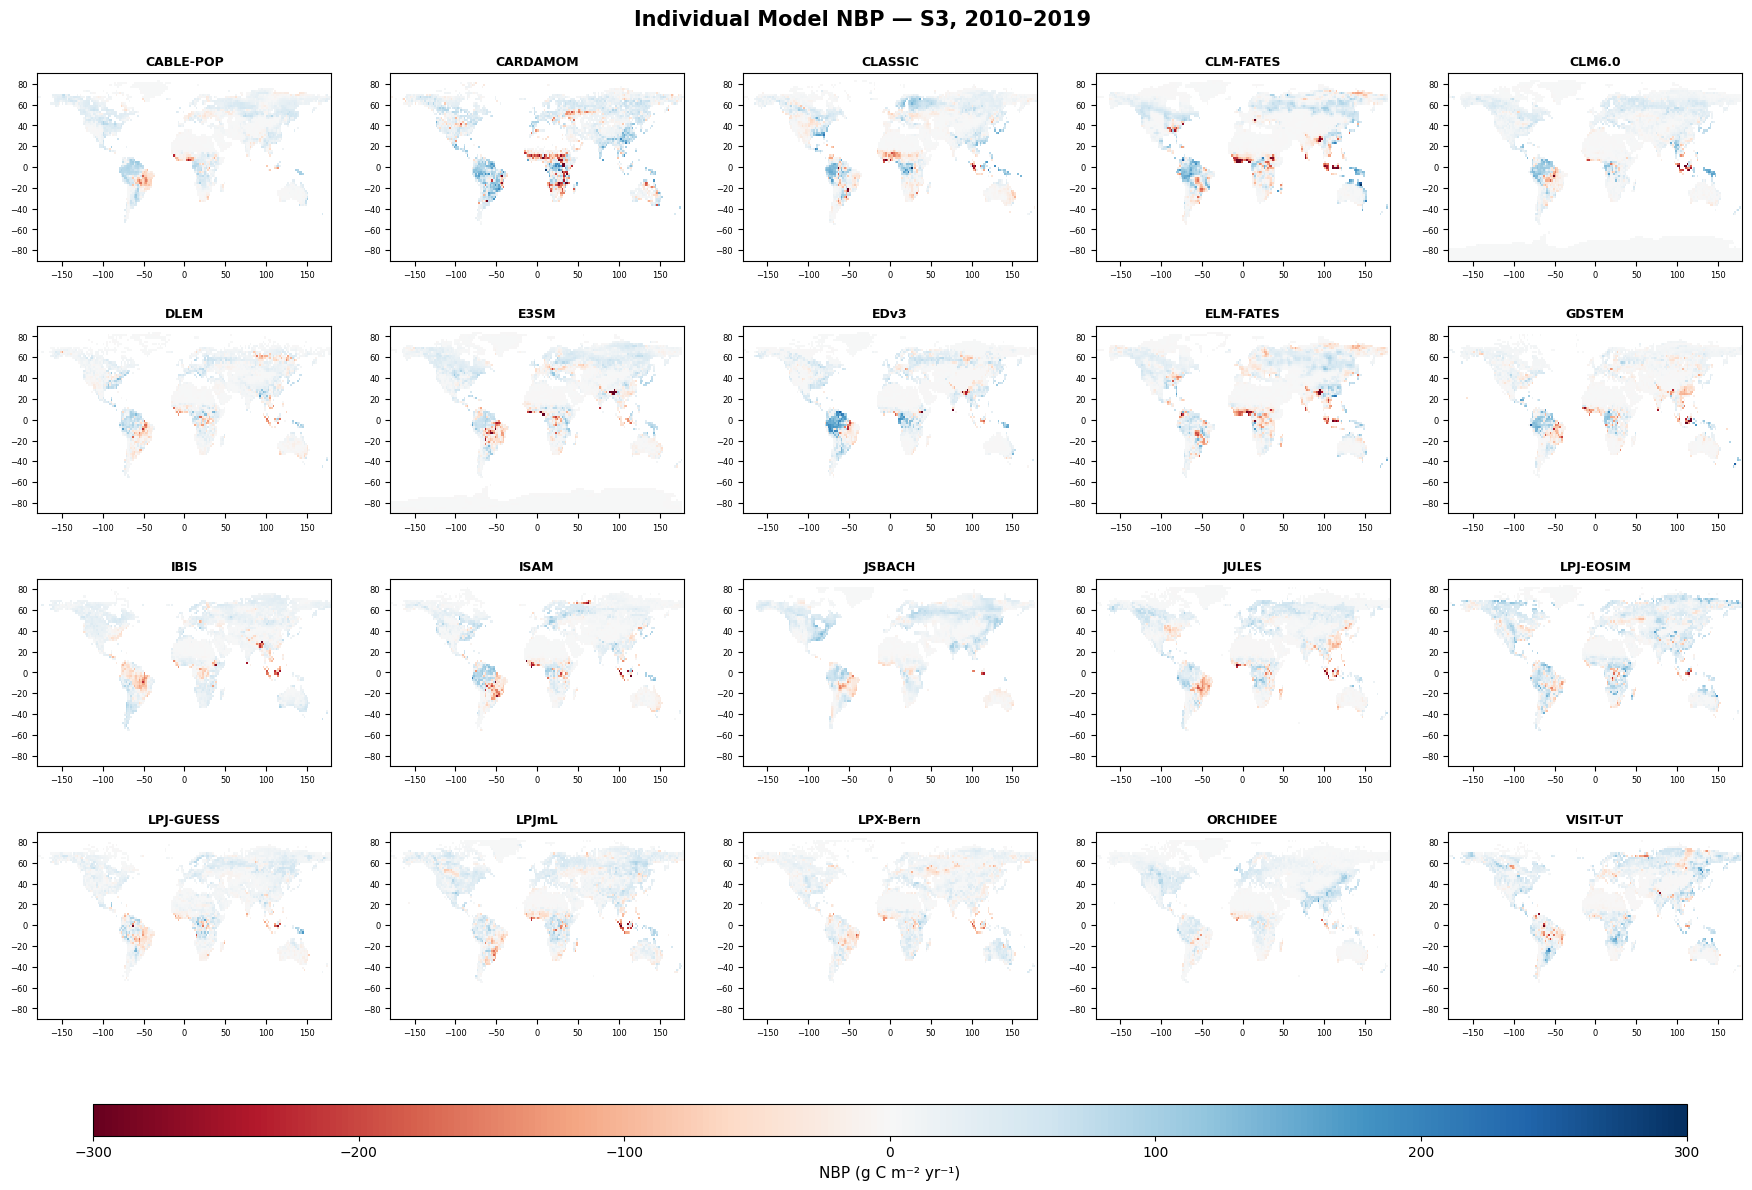

In [11]:
target_decade = 2010
exp = 'S3'

# Models that have S3 data for this decade
avail = [m for m in models
         if (m, exp) in datasets and target_decade in datasets[(m, exp)].decade.values]

ncols = 5
nrows = int(np.ceil(len(avail) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3.2))

vmax = 300
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu'

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

for idx, model in enumerate(avail):
    ax = axes.flat[idx]
    field = datasets[(model, exp)]['nbp'].sel(decade=target_decade).values * UNIT_FACTOR
    im = ax.pcolormesh(lon, lat, field, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(model, fontsize=9, fontweight='bold')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.tick_params(labelsize=6)

# Hide unused panels
for idx in range(len(avail), len(axes.flat)):
    axes.flat[idx].set_visible(False)

fig.suptitle(f'Individual Model NBP — {exp}, {target_decade}–{target_decade+9}',
             fontsize=15, fontweight='bold')
fig.subplots_adjust(bottom=0.1, top=0.93, hspace=0.35)
cbar = fig.colorbar(im, ax=axes, orientation='horizontal',
                    fraction=0.03, pad=0.08, aspect=50)
cbar.set_label('NBP (g C m⁻² yr⁻¹)', fontsize=11)
plt.show()

## Inter-Model Agreement

Fraction of models that agree on the **sign** of NBP (sink vs source) for the 2010s under S3. Values near 1 indicate strong agreement.

/tmp/ipykernel_2073767/2962567571.py:15: RuntimeWarning: Mean of empty slice
  mmm = np.nanmean(stack, axis=0)


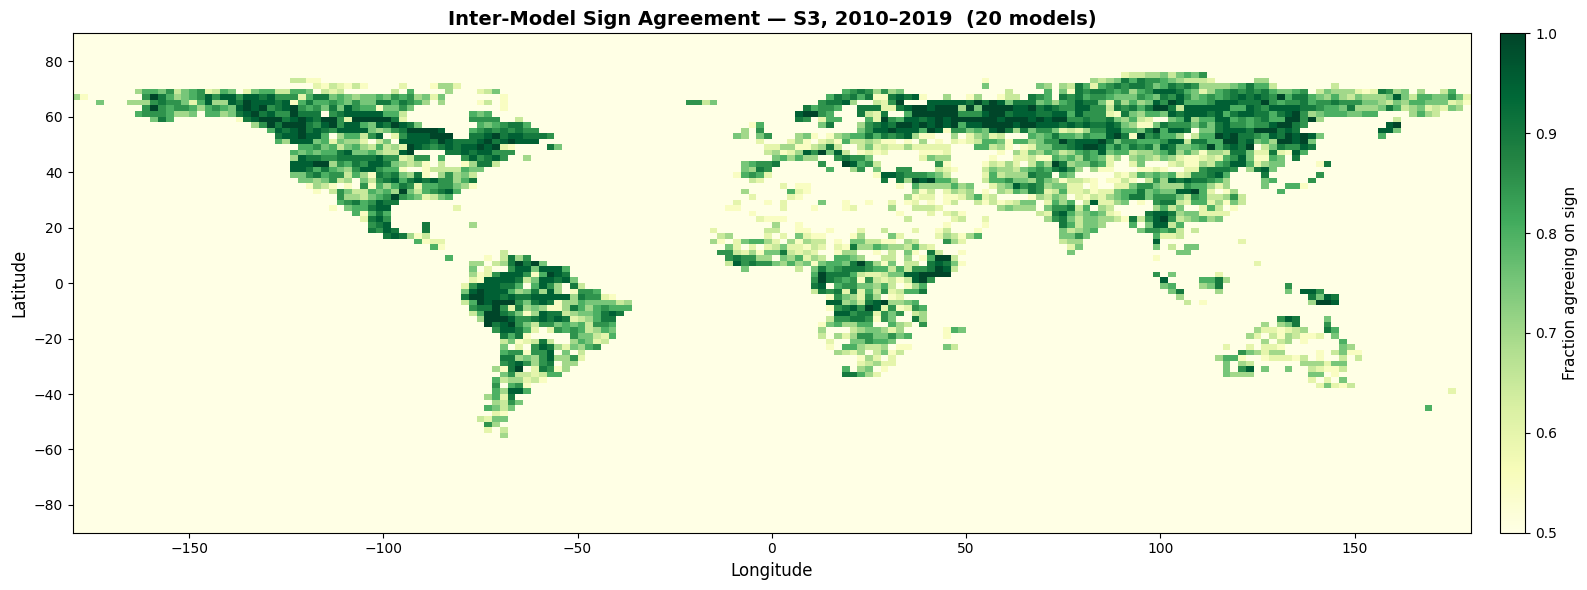

In [6]:
target_decade = 2010
exp = 'S3'

fields = []
for model in models:
    if (model, exp) in datasets:
        ds = datasets[(model, exp)]
        if target_decade in ds.decade.values:
            fields.append(ds['nbp'].sel(decade=target_decade).values)

stack = np.array(fields)  # (n_models, lat, lon)
n_models = stack.shape[0]

# Fraction agreeing on the sign of the multi-model mean
mmm = np.nanmean(stack, axis=0)
sign_mmm = np.sign(mmm)
agree = np.nansum(np.sign(stack) == sign_mmm[np.newaxis, :, :], axis=0) / n_models

lat = datasets[list(datasets.keys())[0]].lat.values
lon = datasets[list(datasets.keys())[0]].lon.values

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.pcolormesh(lon, lat, agree, cmap='YlGn', vmin=0.5, vmax=1.0, shading='auto')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Inter-Model Sign Agreement — {exp}, {target_decade}–{target_decade+9}  ({n_models} models)',
             fontsize=14, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Fraction agreeing on sign', fontsize=11)
plt.tight_layout()
plt.show()